# Training Data vs Model Output Distribution Analysis

Goal: Compare relation/type distributions in training data vs model predictions to identify data skew and model biases.

## 1. Setup and Load Data

In [2]:
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

TRAIN_PATH = Path("./data/train.jsonl")
VAL_PATH   = Path("./data/val.jsonl")

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_data = load_jsonl(TRAIN_PATH)
val_data   = load_jsonl(VAL_PATH)

print(f"Train examples: {len(train_data)}")
print(f"Val examples:   {len(val_data)}")

Train examples: 1800
Val examples:   199


## 2. Parse Triplets from Training Data

Training data is in prompt/completion format. We parse the JSON from completions.

In [12]:
train_data[0]["messages"][2]["content"]

'{"triplets": [{"subject": "John David McPhun", "object": "September 8, 1940", "subject_type": "human", "object_type": "calendar date", "relation": "date of birth", "qualifiers": []}, {"subject": "John David McPhun", "object": "Salisbury, Rhodesia", "subject_type": "human", "object_type": "geographic location", "relation": "place of birth", "qualifiers": []}, {"subject": "John David McPhun", "object": "first-class cricketer", "subject_type": "human", "object_type": "profession", "relation": "occupation", "qualifiers": []}, {"subject": "John David McPhun", "object": "Rhodesia cricket team", "subject_type": "human", "object_type": "sports team", "relation": "member of sports team", "qualifiers": []}, {"subject": "Rhodesia cricket team", "object": "Currie Cup", "subject_type": "sports team", "object_type": "sports competition", "relation": "participant in", "qualifiers": []}]}'

In [13]:
def parse_completion_triplets(example):
    """Extract triplets from the completion field."""
    completion = example.get("messages")[2]["content"]
    try:
        data = json.loads(completion)
        if isinstance(data, dict) and "triplets" in data:
            return data["triplets"]
    except (json.JSONDecodeError, TypeError):
        pass
    return []

train_triplets = []
train_parse_failures = 0
for ex in train_data:
    triplets = parse_completion_triplets(ex)
    if not triplets:
        train_parse_failures += 1
    train_triplets.extend(triplets)

val_triplets_gt = []
val_parse_failures = 0
for ex in val_data:
    triplets = parse_completion_triplets(ex)
    if not triplets:
        val_parse_failures += 1
    val_triplets_gt.extend(triplets)

print(f"Train triplets parsed: {len(train_triplets)} | Failures: {train_parse_failures}")
print(f"Val triplets parsed:   {len(val_triplets_gt)} | Failures: {val_parse_failures}")

Train triplets parsed: 20203 | Failures: 0
Val triplets parsed:   2109 | Failures: 0


## 3. Training Data Statistics

In [14]:
def compute_stats(triplets, label="Training"):
    relations = [t.get("relation", "UNKNOWN") for t in triplets]
    subject_types = [t.get("subject_type", "UNKNOWN") for t in triplets]
    object_types = [t.get("object_type", "UNKNOWN") for t in triplets]

    qualifiers = []
    for t in triplets:
        for q in t.get("qualifiers", []):
            qualifiers.append(q.get("relation", "UNKNOWN"))

    stats = {
        "total_triplets": len(triplets),
        "relation_counts": Counter(relations),
        "subject_type_counts": Counter(subject_types),
        "object_type_counts": Counter(object_types),
        "qualifier_counts": Counter(qualifiers),
    }

    print(f"\n=== {label} Statistics ===")
    print(f"Total triplets: {stats['total_triplets']}")
    print(f"Unique relations: {len(stats['relation_counts'])}")
    print(f"Unique subject types: {len(stats['subject_type_counts'])}")
    print(f"Unique object types: {len(stats['object_type_counts'])}")
    print(f"Total qualifiers: {len(qualifiers)}")
    print(f"Unique qualifier relations: {len(stats['qualifier_counts'])}")

    # Show top relations
    print(f"\nTop 15 relations:")
    for rel, cnt in stats["relation_counts"].most_common(15):
        pct = cnt / len(triplets) * 100
        print(f"  {rel}: {cnt} ({pct:.1f}%)")

    # Show top subject types
    print(f"\nTop 10 subject types:")
    for st, cnt in stats["subject_type_counts"].most_common(10):
        pct = cnt / len(triplets) * 100
        print(f"  {st}: {cnt} ({pct:.1f}%)")

    # Show top qualifier relations
    if qualifiers:
        print(f"\nTop 5 qualifier relations:")
        for qr, cnt in stats["qualifier_counts"].most_common(5):
            pct = cnt / len(qualifiers) * 100
            print(f"  {qr}: {cnt} ({pct:.1f}%)")

    return stats

train_stats = compute_stats(train_triplets, "Training Data")
val_stats   = compute_stats(val_triplets_gt, "Validation Ground Truth")


=== Training Data Statistics ===
Total triplets: 20203
Unique relations: 740
Unique subject types: 687
Unique object types: 1057
Total qualifiers: 8682
Unique qualifier relations: 1294

Top 15 relations:
  instance of: 1300 (6.4%)
  has part(s): 967 (4.8%)
  occupation: 925 (4.6%)
  part of: 494 (2.4%)
  date of birth: 452 (2.2%)
  location: 450 (2.2%)
  position held: 431 (2.1%)
  country of citizenship: 421 (2.1%)
  notable work: 345 (1.7%)
  film crew member: 321 (1.6%)
  participant in: 284 (1.4%)
  award received: 276 (1.4%)
  member of: 275 (1.4%)
  genre: 268 (1.3%)
  inception: 262 (1.3%)

Top 10 subject types:
  human: 5947 (29.4%)
  film: 1517 (7.5%)
  musical group: 591 (2.9%)
  organization: 559 (2.8%)
  album: 558 (2.8%)
  television series: 547 (2.7%)
  musical work: 435 (2.2%)
  building: 397 (2.0%)
  company: 349 (1.7%)
  sports team: 293 (1.5%)

Top 5 qualifier relations:
  point in time: 1871 (21.6%)
  start time: 313 (3.6%)
  location: 263 (3.0%)
  end time: 254 (2.

## 4. Visualize Training Distributions

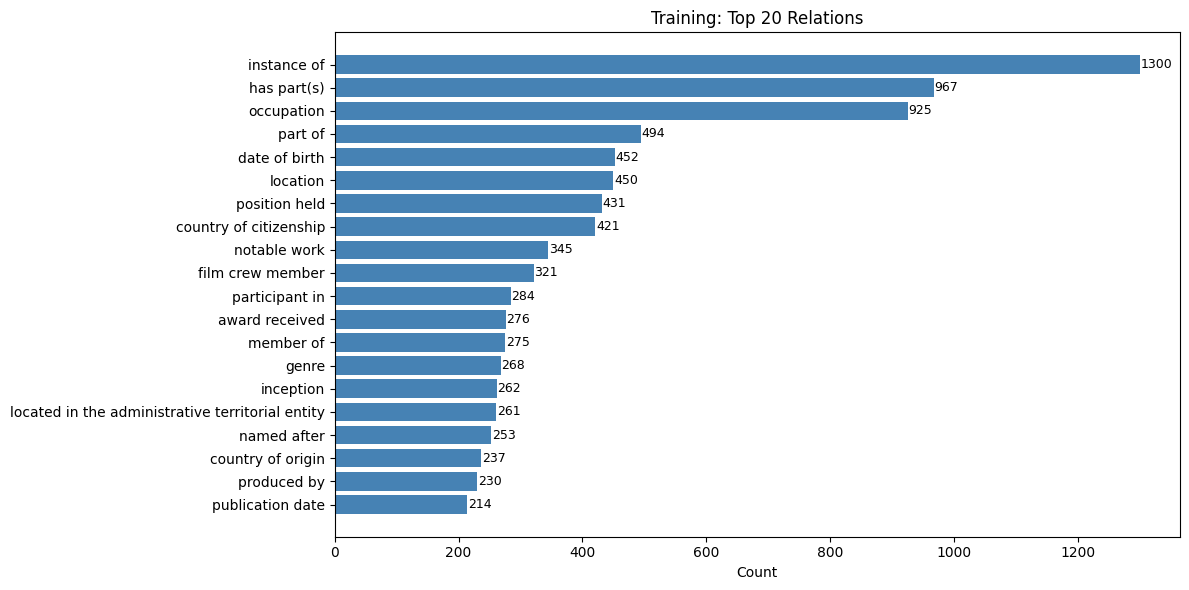

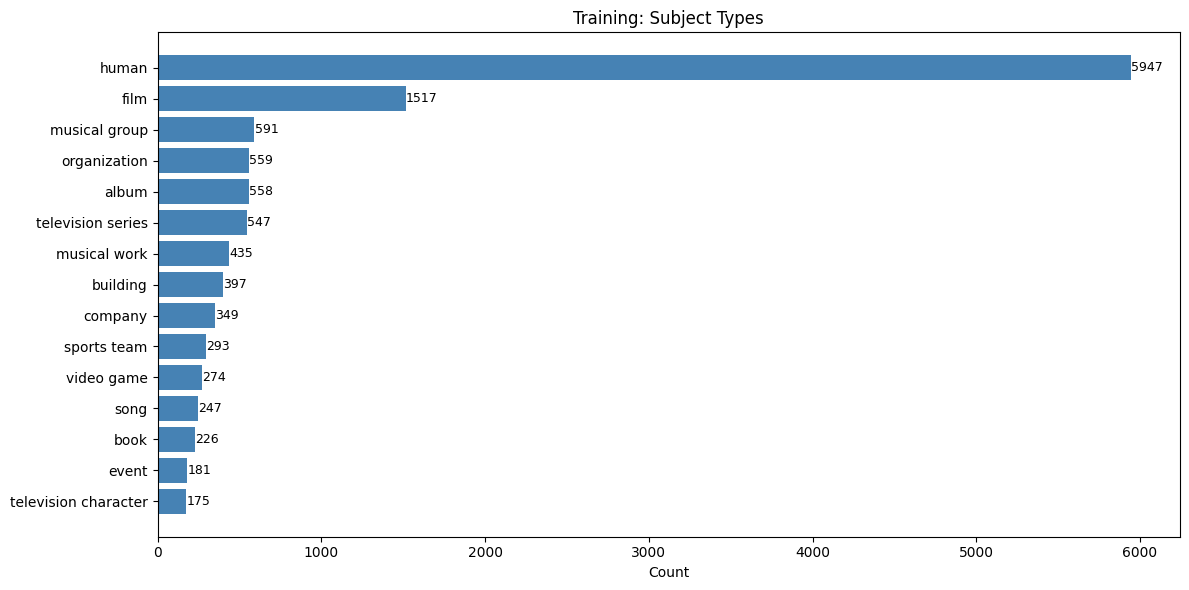

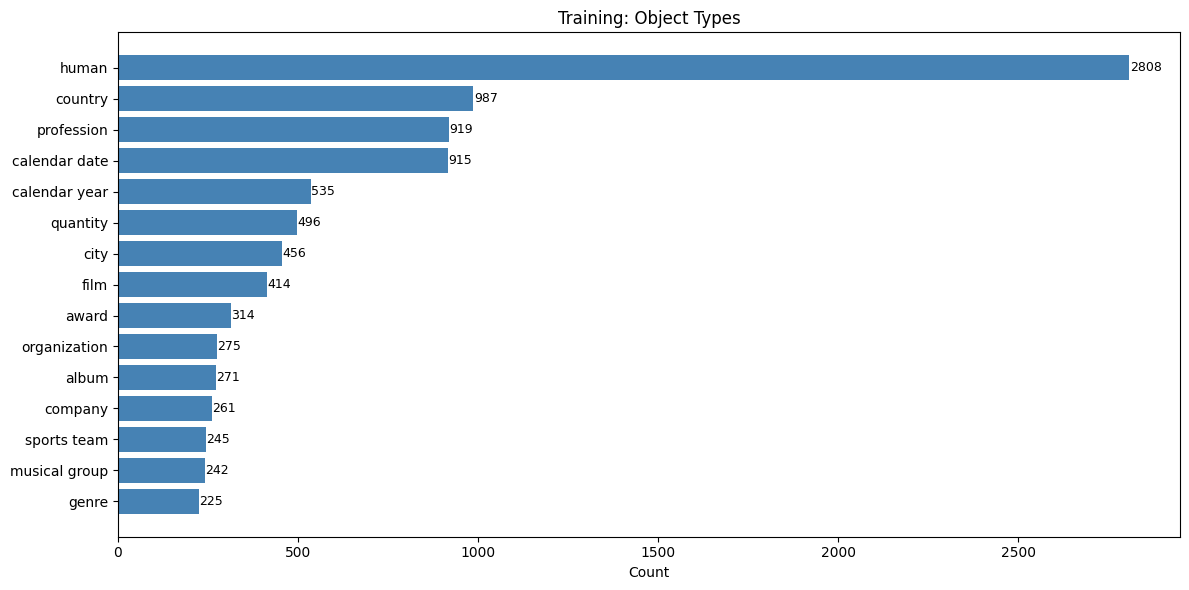

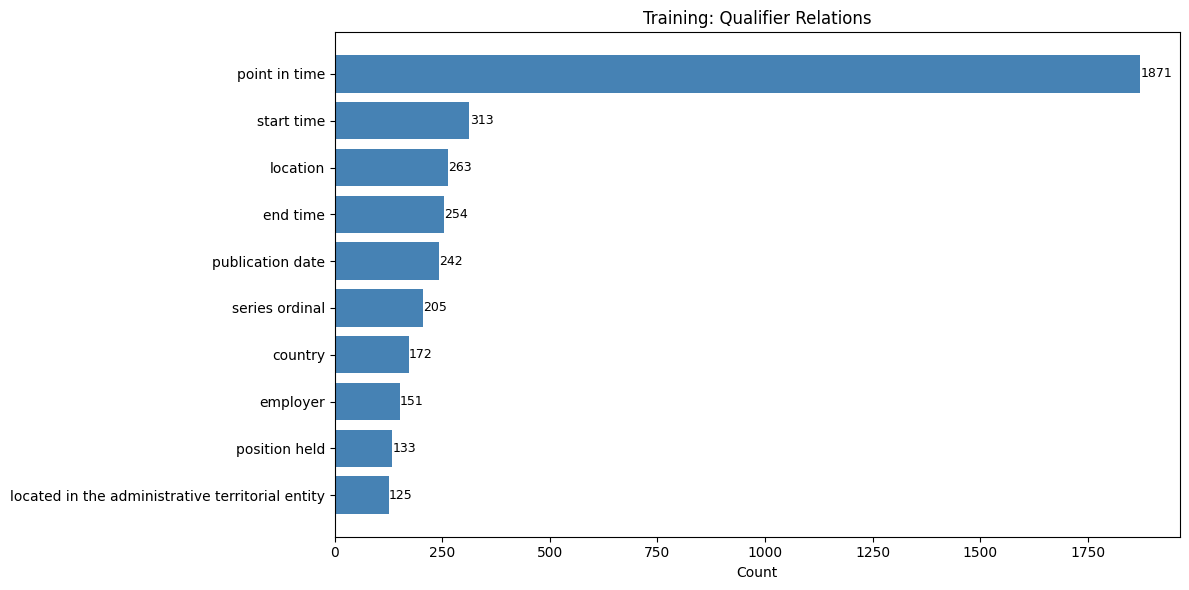

In [15]:
def plot_distribution(counter, title, top_n=20, figsize=(12, 6)):
    items = counter.most_common(top_n)
    labels, values = zip(*items) if items else ([], [])

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(range(len(labels)), values, color='steelblue')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(title)

    # Add count labels on bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

plot_distribution(train_stats["relation_counts"], "Training: Top 20 Relations")
plot_distribution(train_stats["subject_type_counts"], "Training: Subject Types", top_n=15)
plot_distribution(train_stats["object_type_counts"], "Training: Object Types", top_n=15)
if train_stats["qualifier_counts"]:
    plot_distribution(train_stats["qualifier_counts"], "Training: Qualifier Relations", top_n=10)

## 5. Triplets per Example Statistics

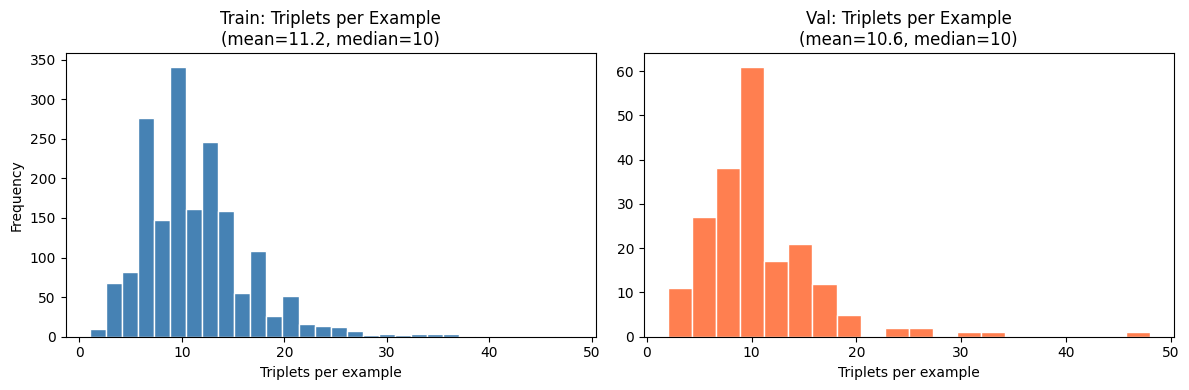

Train triplets/example: min=1, max=48, mean=11.2
Val triplets/example:   min=2, max=48, mean=10.6


In [16]:
def triplets_per_example(examples):
    counts = []
    for ex in examples:
        triplets = parse_completion_triplets(ex)
        counts.append(len(triplets))
    return counts

train_tpe = triplets_per_example(train_data)
val_tpe   = triplets_per_example(val_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_tpe, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f"Train: Triplets per Example\n(mean={np.mean(train_tpe):.1f}, median={np.median(train_tpe):.0f})")
axes[0].set_xlabel("Triplets per example")
axes[0].set_ylabel("Frequency")

axes[1].hist(val_tpe, bins=20, color='coral', edgecolor='white')
axes[1].set_title(f"Val: Triplets per Example\n(mean={np.mean(val_tpe):.1f}, median={np.median(val_tpe):.0f})")
axes[1].set_xlabel("Triplets per example")

plt.tight_layout()
plt.show()

print(f"Train triplets/example: min={min(train_tpe)}, max={max(train_tpe)}, mean={np.mean(train_tpe):.1f}")
print(f"Val triplets/example:   min={min(val_tpe)}, max={max(val_tpe)}, mean={np.mean(val_tpe):.1f}")

## 6. Run Inference on Validation Set

Load model and generate predictions for all validation examples.

In [17]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

BASE_MODEL = "HuggingFaceTB/SmolLM2-1.7B-Instruct"
CHECKPOINT_DIR = "./checkpoints/wikontic-full-pipeline"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, CHECKPOINT_DIR)
model.eval()

print("Model loaded.")

D:\PycharmProjects\Wikontic\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer...


Loading base model...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:03<00:00, 60.69it/s]


Loading LoRA adapter...
Model loaded.


In [19]:
val_data[0]

{'messages': [{'role': 'system',
   'content': 'You are an algorithm designed to extract structured knowledge from texts to build a Wikidata-like knowledge graph. A knowledge graph consists of **triplets** in the format (subject, relation, object), where:\n\n- **Subject**: A named entity or a concept that describes a group of people, events, or any abstract objects that serves as the source of the relation.\n- **Relation**: A Wikidata-style predicate that connects the subject and object.\n- **Object**: A named entity or a concept that describes a group of people, events, or any abstract objects that is related to the subject.\n\nAdditionally, some triplets may have **qualifiers** that provide more context (e.g., date, place, or other attributes). Qualifiers should have relations and object like triplets do, but instead of subject their relation connects an object and the triplet qualifier belongs to. **Qualifiers must always be attached to a triplet** and never exist as standalone trip

In [20]:
# Extract text from validation prompts for inference
def extract_text_from_prompt(prompt):
    """Extract the user text portion from a formatted prompt."""
    # Try to find the Text: "..." pattern
    marker = 'Text: "'
    idx = prompt.find(marker)
    if idx >= 0:
        start = idx + len(marker)
        # Find closing quote at end of line/content
        end = prompt.find('"', start)
        if end >= 0:
            return prompt[start:end]
    # Fallback: return whole prompt
    return prompt

# Validation texts
val_texts = [extract_text_from_prompt(ex["messages"][1]["content"]) for ex in val_data]
print(f"Extracted {len(val_texts)} validation texts.")
print("Example:", val_texts[0][:200], "...")

Extracted 199 validation texts.
Example: The 1991 Currie Cup (known as the  ...


In [21]:
def robust_extract_triplets(text):
    """Robust triplet extractor with multiple fallback strategies."""
    # Attempt 1: Clean trailing garbage and parse full JSON
    cleaned = text.rstrip(". \n\t")
    try:
        data = json.loads(cleaned)
        if isinstance(data, dict) and "triplets" in data:
            return data
    except (json.JSONDecodeError, TypeError):
        pass

    # Attempt 2: Find JSON object with brace-depth matching
    candidates = []
    for i, ch in enumerate(text):
        if ch == "{":
            depth = 1
            for j in range(i + 1, len(text)):
                if text[j] == "{":
                    depth += 1
                elif text[j] == "}":
                    depth -= 1
                    if depth == 0:
                        candidates.append(text[i:j+1])
                        break

    triplets = []
    seen = set()
    for candidate in candidates:
        if '"subject"' not in candidate or '"relation"' not in candidate or '"object"' not in candidate:
            continue
        try:
            obj = json.loads(candidate)
            if isinstance(obj, dict) and all(k in obj for k in ("subject", "relation", "object")):
                key = (obj.get("subject"), obj.get("relation"), obj.get("object"))
                if key not in seen:
                    seen.add(key)
                    triplets.append(obj)
        except (json.JSONDecodeError, TypeError):
            pass

    if triplets:
        return {"triplets": triplets}

    return None

def inference(text, max_new_tokens=2048):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f'Text: "{text}"'},
    ]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.0,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    full_output = tokenizer.decode(output[0], skip_special_tokens=False)

    # Extract assistant portion
    marker = "\nassistant\n"
    marker_pos = full_output.find(marker)
    if marker_pos >= 0:
        answer = full_output[marker_pos + len(marker):].strip()
    else:
        answer = full_output[len(prompt):].strip()

    # Strip trailing hallucinated turns
    for turn_marker in ["<|im_start|>user", "<|im_start|>system", "<|endoftext|>", "</s>"]:
        pos = answer.find(turn_marker)
        if pos >= 0:
            answer = answer[:pos].strip()

    return answer

# Load system prompt
SYSTEM_PROMPT_PATH = Path("../src/wikontic/utils/prompts/triplet_extraction/propmt_1_types_qualifiers.txt")
SYSTEM_PROMPT = open(SYSTEM_PROMPT_PATH, encoding="utf-8").read()
print(f"System prompt loaded: {len(SYSTEM_PROMPT)} chars")

System prompt loaded: 4034 chars


In [22]:
# Run inference on validation set (this may take a while)
val_predictions = []
val_parsed = []
parse_successes = 0
empty_outputs = 0

for i, text in enumerate(val_texts):
    raw = inference(text)
    parsed = robust_extract_triplets(raw)

    val_predictions.append({
        "text": text,
        "raw_output": raw,
        "parsed": parsed,
    })

    if parsed and "triplets" in parsed:
        parse_successes += 1
        if len(parsed["triplets"]) == 0:
            empty_outputs += 1
    else:
        val_parsed.append([])
        continue

    val_parsed.append(parsed["triplets"])

    if (i + 1) % 20 == 0:
        print(f"  Processed {i+1}/{len(val_texts)}...")

print(f"\nDone!")
print(f"Parse success rate: {parse_successes}/{len(val_texts)} ({parse_successes/len(val_texts)*100:.1f}%)")
print(f"Empty outputs (parsed but zero triplets): {empty_outputs}")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Processed 20/199...
  Processed 40/199...
  Processed 60/199...
  Processed 80/199...
  Processed 100/199...
  Processed 120/199...
  Processed 140/199...
  Processed 160/199...
  Processed 180/199...

Done!
Parse success rate: 193/199 (97.0%)
Empty outputs (parsed but zero triplets): 0


In [23]:
# Save predictions for later inspection
import pickle

with open("./data/val_predictions.pkl", "wb") as f:
    pickle.dump(val_predictions, f)

print("Saved predictions to ./data/val_predictions.pkl")

Saved predictions to ./data/val_predictions.pkl


## 7. Model Output Statistics

In [24]:
pred_triplets = []
for triplets in val_parsed:
    pred_triplets.extend(triplets)

pred_stats = compute_stats(pred_triplets, "Model Predictions")

# Triplets per predicted example
pred_tpe = [len(t) for t in val_parsed]
print(f"\nPredictions triplets/example: min={min(pred_tpe)}, max={max(pred_tpe)}, mean={np.mean(pred_tpe):.1f}")


=== Model Predictions Statistics ===
Total triplets: 1033
Unique relations: 134
Unique subject types: 80
Unique object types: 180
Total qualifiers: 195
Unique qualifier relations: 7

Top 15 relations:
  instance of: 223 (21.6%)
  occupation: 174 (16.8%)
  award received: 78 (7.6%)
  date of birth: 58 (5.6%)
  date of death: 38 (3.7%)
  field of work: 33 (3.2%)
  located in: 29 (2.8%)
  record label: 28 (2.7%)
  is a part of: 27 (2.6%)
  proximity: 21 (2.0%)
  award: 17 (1.6%)
  position: 14 (1.4%)
  history: 10 (1.0%)
  operates: 9 (0.9%)
  film: 8 (0.8%)

Top 10 subject types:
  human: 436 (42.2%)
  UNKNOWN: 61 (5.9%)
  person: 49 (4.7%)
  film: 41 (4.0%)
  company: 34 (3.3%)
  geographic_area: 28 (2.7%)
  institution: 26 (2.5%)
  railway: 23 (2.2%)
  record label: 21 (2.0%)
  building: 18 (1.7%)

Top 5 qualifier relations:
  point in time: 148 (75.9%)
  instance of: 37 (19.0%)
  record label: 3 (1.5%)
  color: 3 (1.5%)
  award: 2 (1.0%)

Predictions triplets/example: min=0, max=27, 

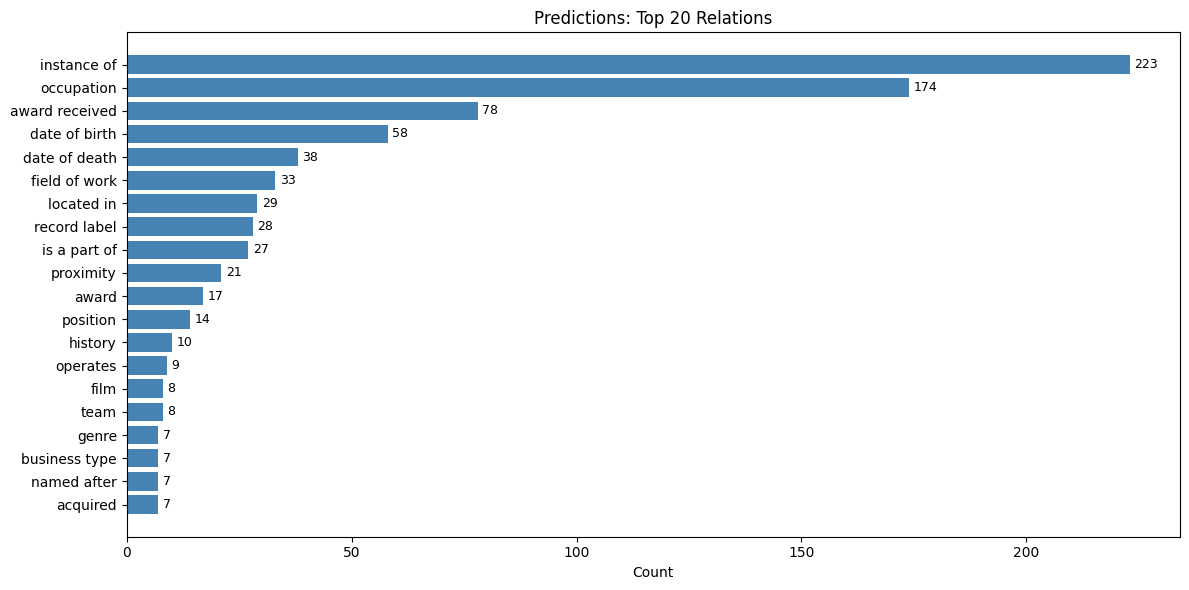

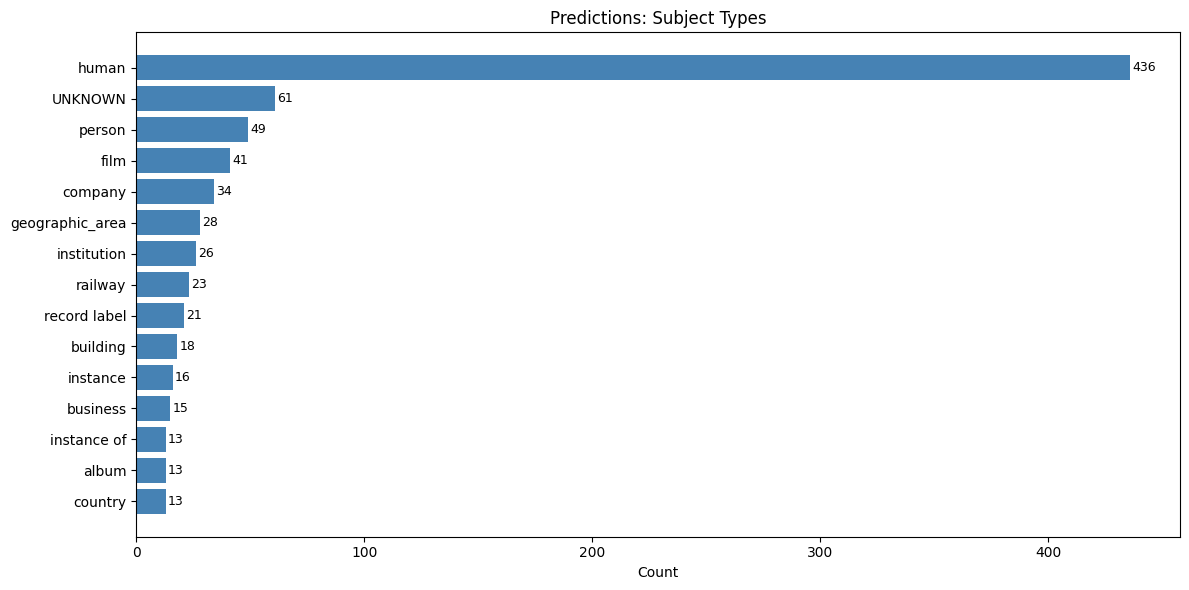

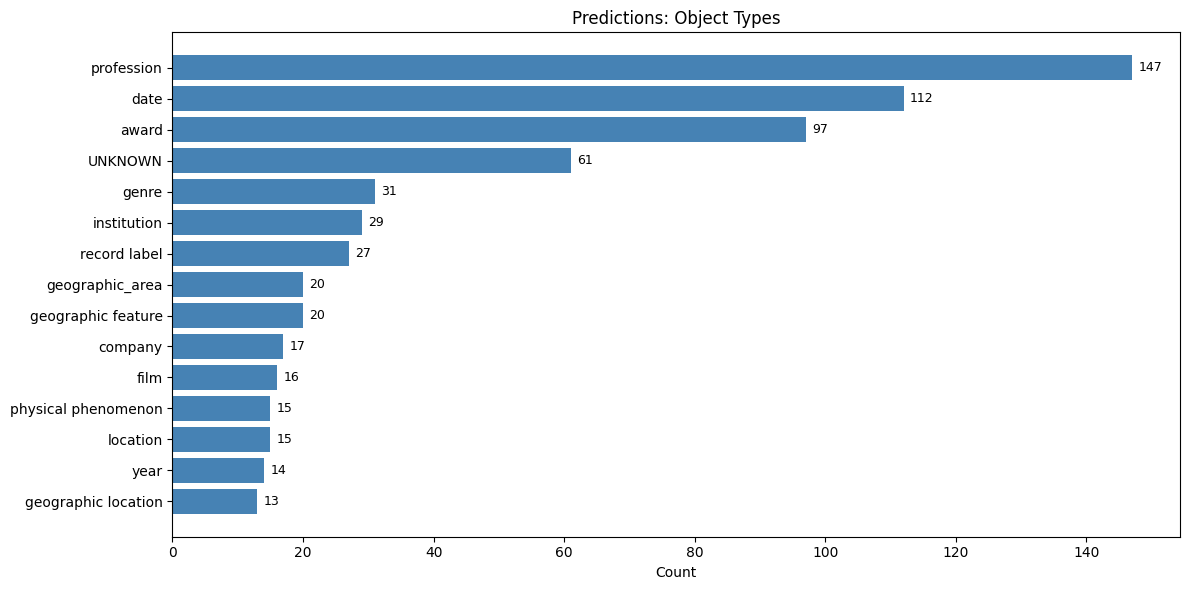

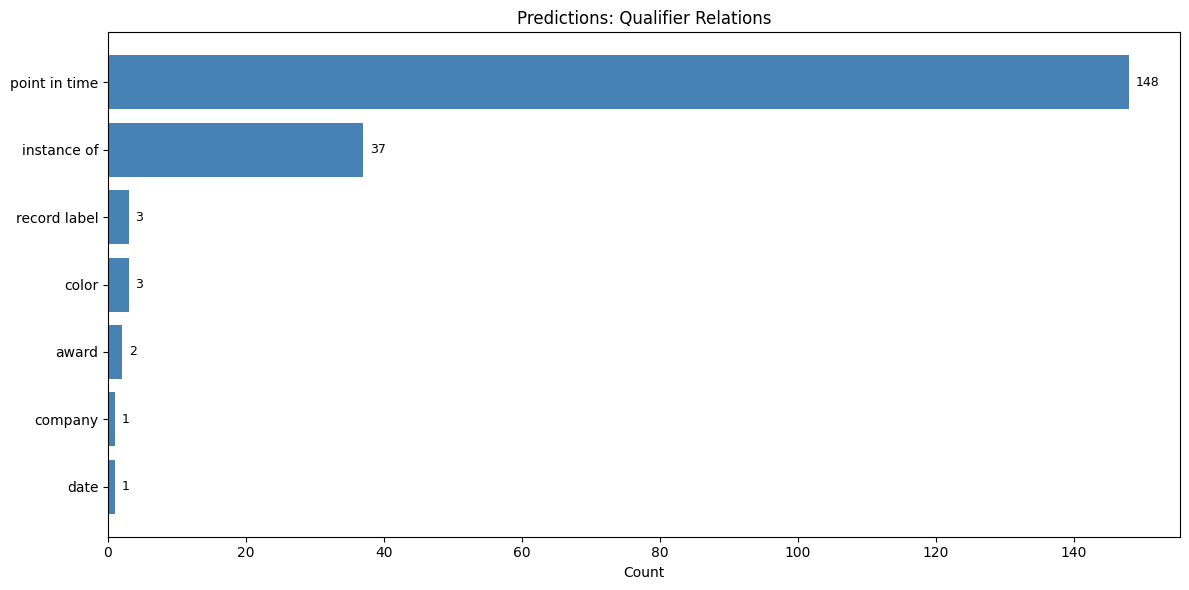

In [25]:
plot_distribution(pred_stats["relation_counts"], "Predictions: Top 20 Relations")
plot_distribution(pred_stats["subject_type_counts"], "Predictions: Subject Types", top_n=15)
plot_distribution(pred_stats["object_type_counts"], "Predictions: Object Types", top_n=15)
if pred_stats["qualifier_counts"]:
    plot_distribution(pred_stats["qualifier_counts"], "Predictions: Qualifier Relations", top_n=10)

## 8. Side-by-Side Comparison

Compare training distribution vs prediction distribution.

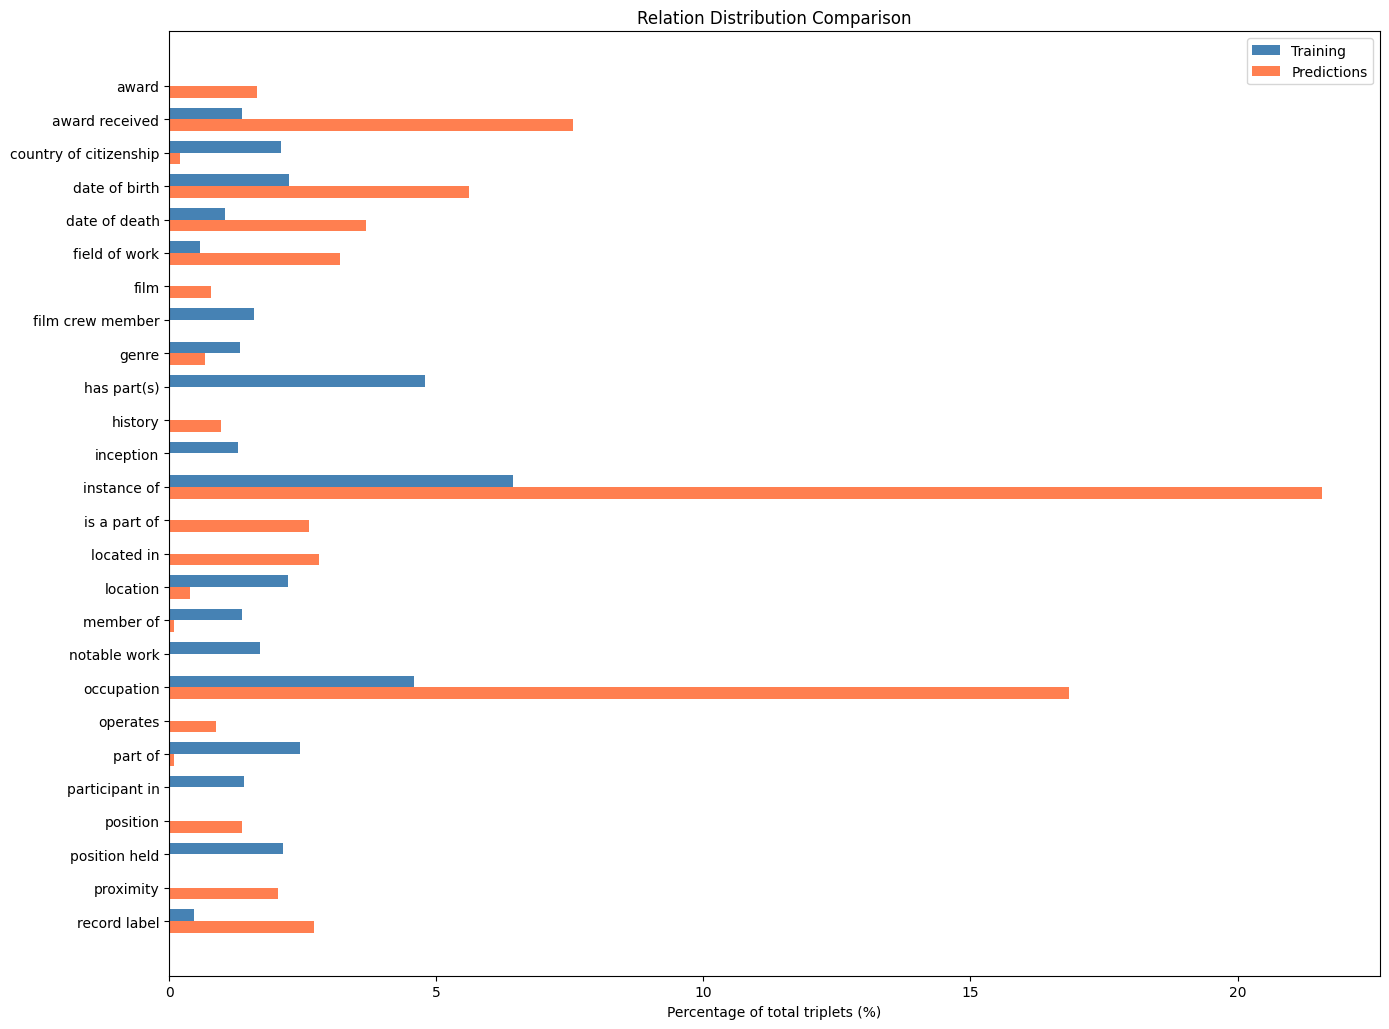

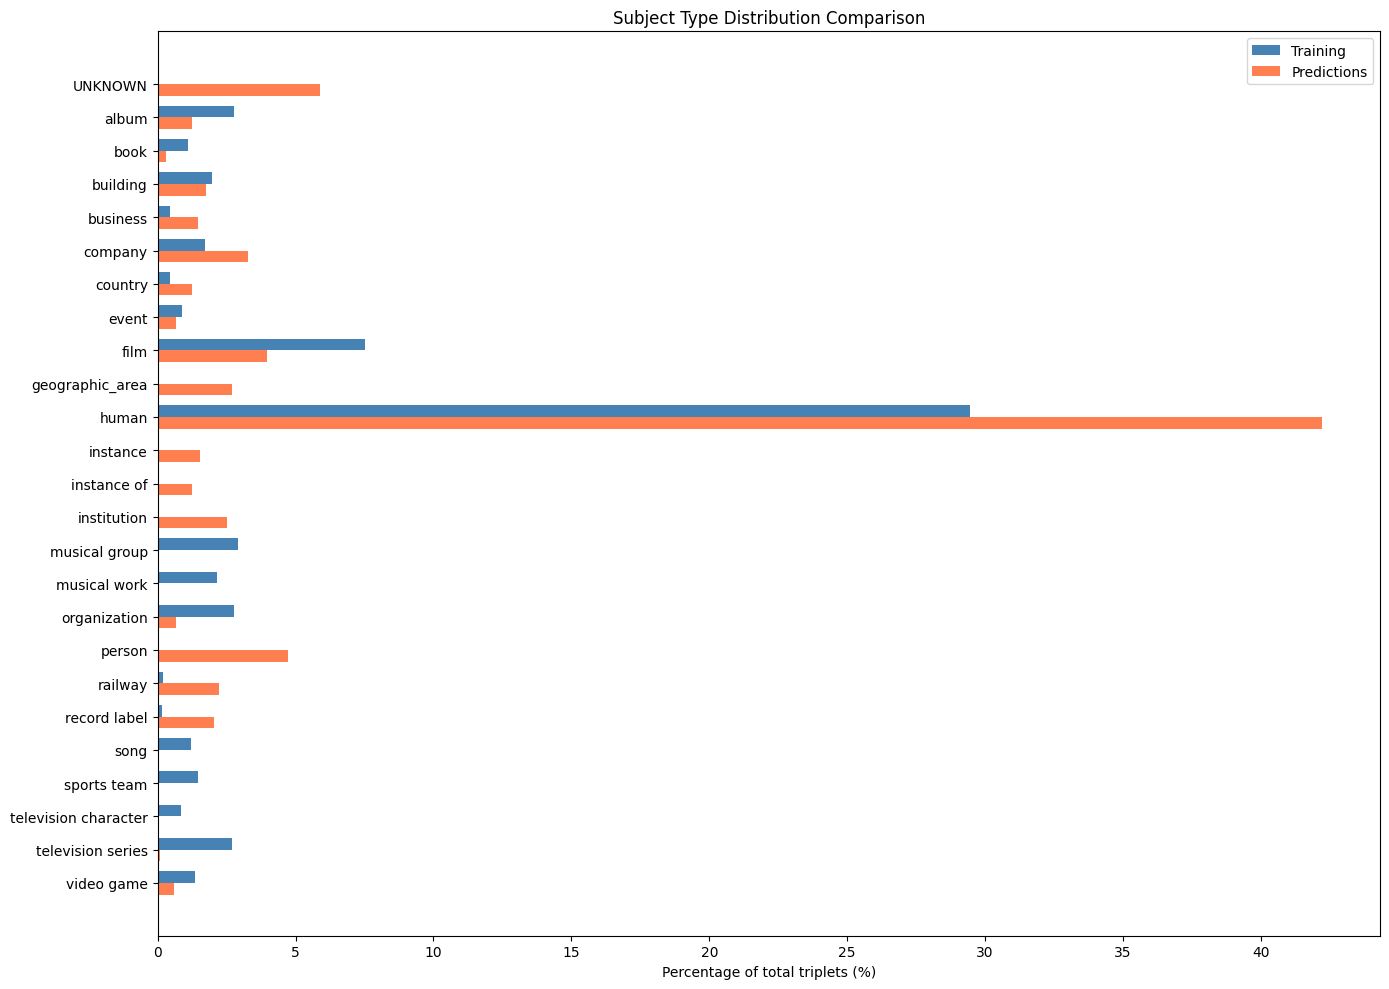

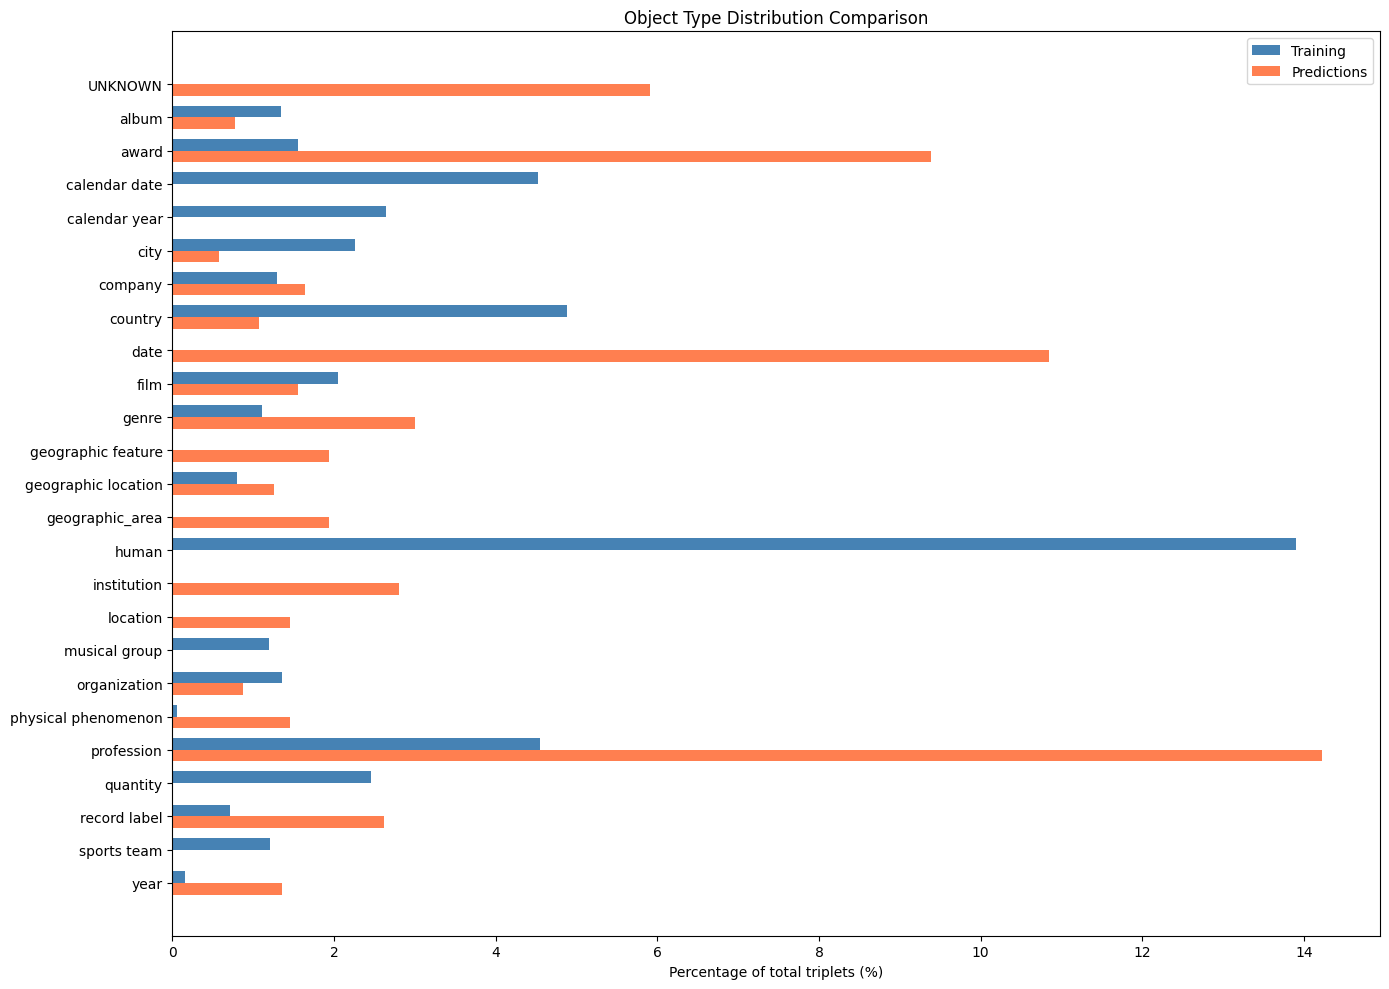

In [26]:
def compare_distributions(train_counter, pred_counter, label, top_n=15):
    """Compare two distributions side by side."""
    # Get union of top items from both
    train_top = set([k for k, _ in train_counter.most_common(top_n)])
    pred_top = set([k for k, _ in pred_counter.most_common(top_n)])
    all_keys = sorted(train_top | pred_top)

    train_total = sum(train_counter.values())
    pred_total = sum(pred_counter.values())

    train_pcts = [train_counter.get(k, 0) / train_total * 100 for k in all_keys]
    pred_pcts = [pred_counter.get(k, 0) / pred_total * 100 for k in all_keys]

    x = np.arange(len(all_keys))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, max(4, len(all_keys) * 0.4)))
    ax.barh(x - width/2, train_pcts, width, label='Training', color='steelblue')
    ax.barh(x + width/2, pred_pcts, width, label='Predictions', color='coral')
    ax.set_yticks(x)
    ax.set_yticklabels(all_keys)
    ax.set_xlabel("Percentage of total triplets (%)")
    ax.set_title(f"{label} Distribution Comparison")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

compare_distributions(train_stats["relation_counts"], pred_stats["relation_counts"], "Relation")
compare_distributions(train_stats["subject_type_counts"], pred_stats["subject_type_counts"], "Subject Type")
compare_distributions(train_stats["object_type_counts"], pred_stats["object_type_counts"], "Object Type")

In [27]:
# Relation ranking comparison
train_rel_rank = {rel: i for i, (rel, _) in enumerate(train_stats["relation_counts"].most_common())}
pred_rel_rank = {rel: i for i, (rel, _) in enumerate(pred_stats["relation_counts"].most_common())}

print("=== Relation Ranking Comparison (Top 20) ===")
print(f"{'Relation':<35} {'Train Rank':<12} {'Pred Rank':<12} {'Diff':<8}")
print("-" * 75)
for rel, _ in train_stats["relation_counts"].most_common(20):
    tr = train_rel_rank.get(rel, "-")
    pr = pred_rel_rank.get(rel, "-")
    if isinstance(tr, int) and isinstance(pr, int):
        diff = pr - tr
        diff_str = f"{diff:+d}"
    else:
        diff_str = "N/A"
    print(f"{rel:<35} {str(tr):<12} {str(pr):<12} {diff_str:<8}")

# Qualifier comparison
print("\n=== Qualifier Relation Comparison ===")
train_q_top = [q for q, _ in train_stats["qualifier_counts"].most_common(10)]
pred_q_top = [q for q, _ in pred_stats["qualifier_counts"].most_common(10)]
print(f"Train top qualifiers:    {train_q_top}")
print(f"Predict top qualifiers:  {pred_q_top}")

=== Relation Ranking Comparison (Top 20) ===
Relation                            Train Rank   Pred Rank    Diff    
---------------------------------------------------------------------------
instance of                         0            0            +0      
has part(s)                         1            -            N/A     
occupation                          2            1            -1      
part of                             3            86           +83     
date of birth                       4            3            -1      
location                            5            32           +27     
position held                       6            -            N/A     
country of citizenship              7            66           +59     
notable work                        8            -            N/A     
film crew member                    9            -            N/A     
participant in                      10           -            N/A     
award received             

## 9. Chi-Squared Test for Distribution Difference

Statistical test to check if prediction relation distribution is significantly different from training.

In [29]:
from scipy.stats import chisquare

# Use top-N relations shared by both to avoid zero-count issues
common_rels = set(train_stats["relation_counts"].keys()) & set(pred_stats["relation_counts"].keys())
common_rels = sorted(common_rels, key=lambda r: train_stats["relation_counts"][r], reverse=True)[:30]

train_counts = np.array([train_stats["relation_counts"][r] for r in common_rels])
pred_counts = np.array([pred_stats["relation_counts"][r] for r in common_rels])

# Normalize training to prediction total for expected frequencies
pred_total = sum(pred_counts)
train_total = sum(train_counts)
expected = train_counts / train_total * pred_total

# Chi-squared test
chi2, p_value = chisquare(f_obs=pred_counts, f_exp=expected)

print(f"Chi-squared statistic: {chi2:.2f}")
print(f"p-value: {p_value:.2e}")
if p_value < 0.05:
    print("RESULT: Predicted relation distribution is SIGNIFICANTLY different from training (p < 0.05)")
else:
    print("RESULT: No significant difference detected (p >= 0.05)")

# Show per-relation residuals (observed - expected)
residuals = pred_counts - expected
print("\nTop over-represented in predictions (residual > 0):")
for i in np.argsort(residuals)[::-1][:10]:
    print(f"  {common_rels[i]}: residual={residuals[i]:.1f}, pred={pred_counts[i]}, expected={expected[i]:.1f}")

print("\nTop under-represented in predictions (residual < 0):")
for i in np.argsort(residuals)[:10]:
    print(f"  {common_rels[i]}: residual={residuals[i]:.1f}, pred={pred_counts[i]}, expected={expected[i]:.1f}")

Chi-squared statistic: 507.04
p-value: 5.76e-92
RESULT: Predicted relation distribution is SIGNIFICANTLY different from training (p < 0.05)

Top over-represented in predictions (residual > 0):
  instance of: residual=82.9, pred=223, expected=140.1
  occupation: residual=74.3, pred=174, expected=99.7
  award received: residual=48.3, pred=78, expected=29.7
  field of work: residual=20.4, pred=33, expected=12.6
  record label: residual=17.8, pred=28, expected=10.2
  date of death: residual=15.4, pred=38, expected=22.6
  date of birth: residual=9.3, pred=58, expected=48.7
  color: residual=2.0, pred=4, expected=2.0
  employees: residual=1.6, pred=2, expected=0.4
  population: residual=0.6, pred=2, expected=1.4

Top under-represented in predictions (residual < 0):
  part of: residual=-52.2, pred=1, expected=53.2
  location: residual=-44.5, pred=4, expected=48.5
  country of citizenship: residual=-43.4, pred=2, expected=45.4
  member of: residual=-28.6, pred=1, expected=29.6
  genre: residua

## 10. Detailed Failure Analysis

Look at specific examples where parse failed or model output was empty.

In [30]:
# Show a few failed parses
failed_examples = [p for p in val_predictions if p["parsed"] is None]
print(f"Failed parses: {len(failed_examples)}")

for i, ex in enumerate(failed_examples[:3]):
    print(f"\n--- Failed Parse {i+1} ---")
    print(f"Text: {ex['text'][:200]}...")
    print(f"Raw output: {ex['raw_output'][:500]}")

# Show a few empty outputs
empty_examples = [p for p in val_predictions if p["parsed"] and len(p["parsed"].get("triplets", [])) == 0]
print(f"\nEmpty outputs: {len(empty_examples)}")
for i, ex in enumerate(empty_examples[:3]):
    print(f"\n--- Empty Output {i+1} ---")
    print(f"Text: {ex['text'][:200]}...")
    print(f"Raw output: {ex['raw_output'][:500]}")

Failed parses: 6

--- Failed Parse 1 ---
Text: Margarethe Siems (20 December 1879 – 13 April 1952) was a German operatic soprano and voice teacher.  A Kammersängerin of the Dresden State Opera, between 1909 and 1912 Siems created leading roles in ...
Raw output: {"triplets": [{"subject": "Margarethe Siems", "relation": "date of birth", "object": "20 December 1879", "qualifiers": [], "subject_type": "human", "object_type": "date", "subject": "Margarethe Siems", "object": "20 December 1879", "object": "human", "object": "date", "object": "20 December 1879", "object": "human", "object": "date", "object": "20 December 1879", "object": "human", "object": "date", "object": "20 December 1879", "object": "human", "object": "date", "object": "20 December 1879", 

--- Failed Parse 2 ---
Text: Frederick Alexander Lindemann, 1st Viscount Cherwell, (5 April 18863 July 1957), pronounced , was a British physicist and an influential scientific adviser to the British government from the early 194...
Ra

## 11. Summary

Key takeaways from the analysis:

In [31]:
# Auto-generated summary stats
print("=== Distribution Analysis Summary ===")
print()
print("TRAINING DATA:")
print(f"  Total triplets: {train_stats['total_triplets']}")
print(f"  Unique relations: {len(train_stats['relation_counts'])}")
print(f"  Top relation: {train_stats['relation_counts'].most_common(1)[0][0]} ({train_stats['relation_counts'].most_common(1)[0][1]} occurrences)")
print(f"  Top 5 relations cover: {sum(c for _, c in train_stats['relation_counts'].most_common(5)) / train_stats['total_triplets'] * 100:.1f}%")
print(f"  Top 10 relations cover: {sum(c for _, c in train_stats['relation_counts'].most_common(10)) / train_stats['total_triplets'] * 100:.1f}%")
print()
print("MODEL PREDICTIONS:")
print(f"  Total triplets: {pred_stats['total_triplets']}")
print(f"  Unique relations: {len(pred_stats['relation_counts'])}")
print(f"  Parse success rate: {parse_successes}/{len(val_texts)} ({parse_successes/len(val_texts)*100:.1f}%)")
print(f"  Empty outputs: {empty_outputs}/{parse_successes}")
print(f"  Top relation: {pred_stats['relation_counts'].most_common(1)[0][0] if pred_stats['relation_counts'] else 'N/A'}")
print()
print("COMPARISON:")
train_top5 = set([r for r, _ in train_stats['relation_counts'].most_common(5)])
pred_top5 = set([r for r, _ in pred_stats['relation_counts'].most_common(5)])
shared_top5 = train_top5 & pred_top5
print(f"  Shared top-5 relations: {len(shared_top5)}/5 ({', '.join(sorted(shared_top5))})")

# Bias metric: is model dominated by top relation?
if pred_stats['relation_counts']:
    top_pred_pct = pred_stats['relation_counts'].most_common(1)[0][1] / sum(pred_stats['relation_counts'].values()) * 100
    top_train_pct = train_stats['relation_counts'].most_common(1)[0][1] / sum(train_stats['relation_counts'].values()) * 100
    print(f"  Top-relation dominance in predictions: {top_pred_pct:.1f}% (training: {top_train_pct:.1f}%)")
    if top_pred_pct > top_train_pct * 1.5:
        print("  ⚠️  WARNING: Model is heavily biased toward the most common relation!")
    else:
        print("  ✅ Top-relation distribution is similar to training.")

=== Distribution Analysis Summary ===

TRAINING DATA:
  Total triplets: 20203
  Unique relations: 740
  Top relation: instance of (1300 occurrences)
  Top 5 relations cover: 20.5%
  Top 10 relations cover: 30.2%

MODEL PREDICTIONS:
  Total triplets: 1033
  Unique relations: 134
  Parse success rate: 193/199 (97.0%)
  Empty outputs: 0/193
  Top relation: instance of

COMPARISON:
  Shared top-5 relations: 3/5 (date of birth, instance of, occupation)
  Top-relation dominance in predictions: 21.6% (training: 6.4%)
  ⚠️  WARNING: Model is heavily biased toward the most common relation!
